# Lab Instructions

You are part of a data team for a financial institution that uses an AI model to determine who will and will not be granted a loan.  Recently, there have been complaints from customers that the model unfairly discriminates based on the applicant's age and sex. A court has ordered that the financial institution must provide information about how the model works.  

Data from recent loan applications is given in `loan_data.csv`.  The data dictionary is below:

| Feature              | Description | Data Type |
| :---------------- | :------: | ----: |
|person_age|Age of the person|Float
|person_gender|Gender of the person|Categorical
|person_education|Highest education level|Categorical
|person_income|Annual income|Float
|person_emp_exp|Years of employment experience|Integer
|person_home_ownership|Home ownership status (e.g., rent, own, mortgage)|Categorical
|loan_amnt|Loan amount requested|Float
|loan_intent|Purpose of the loan|Categorical
|loan_int_rate|Loan interest rate|Float
|loan_percent_income|Loan amount as a percentage of annual income|Float
|cb_person_cred_hist_length|Length of credit history in years|Float
|credit_score|Credit score of the person|Integer
|previous_loan_defaults_on_file|Indicator of previous loan defaults|Categorical
|loan_status (target variable)|Loan approval status: 1 = approved; 0 = rejected|Integer

Visualize the relationship between age, sex and 5 other features with `loan_status`.  Which features seem to drive the model's decision to grant a loan?  Which seem unrelated?  Should the financial institution be concerned about potential legal trouble?  Make sure to justify your answers with specific references to your visualizations.

**You must use quantitative visualizations (boxplots or histograms) when comparing quantitative features.  DO NOT categorize quantitative features.**

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
loandf = pd.read_csv('loan_data.csv')
loandf.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,71,male,Associate,46817.176426,3,RENT,11567.737650,MEDICAL,10.351469,0.247083,5,806.869094,No,0
1,34,male,High School,79093.494008,17,OWN,9519.674498,MEDICAL,11.168902,0.120360,1,604.330171,No,0
2,80,male,Associate,67819.614431,20,OWN,16226.604002,PERSONAL,12.293112,0.239261,11,685.933579,No,0
3,40,female,Associate,49599.861220,0,RENT,15641.221708,VENTURE,10.327926,0.315348,14,629.190150,No,0
4,43,male,Doctorate,99833.900180,8,OWN,12727.942517,EDUCATION,9.338069,0.127491,16,638.298168,No,1


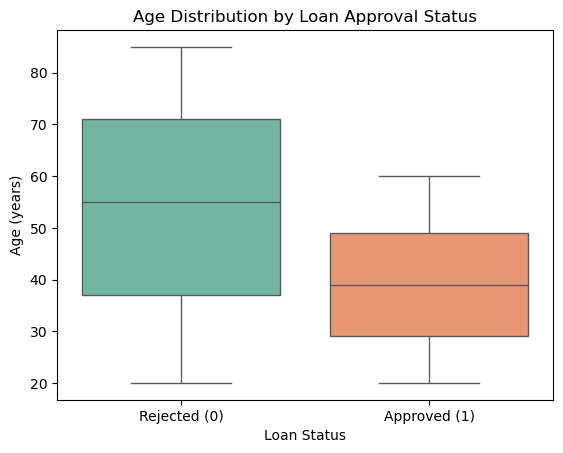

In [5]:

sns.boxplot(
    data=loandf,
    x='loan_status',
    y='person_age',
    hue='loan_status',           # colors the boxes
    palette='Set2',
    legend=False
)
plt.xticks([0,1], ['Rejected (0)', 'Approved (1)'])
plt.xlabel('Loan Status')
plt.ylabel('Age (years)')
plt.title('Age Distribution by Loan Approval Status')
plt.show()

It does look like the majority of regections come from the older applicants.

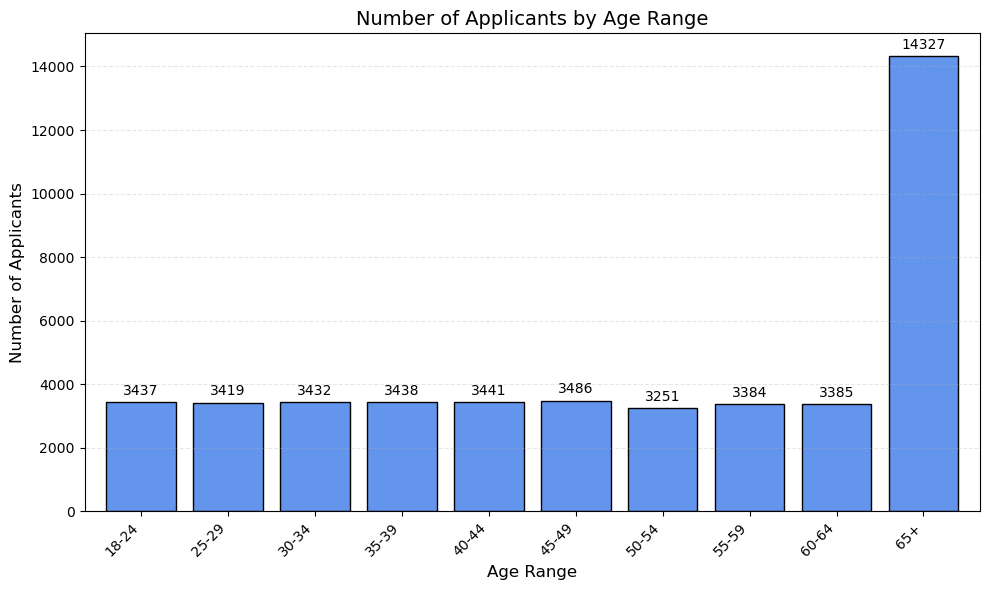

In [26]:
bins = [18, 25, 30, 35, 40, 45, 50, 55, 60, 65, 100]
labels = ['18-24', '25-29', '30-34', '35-39', '40-44', '45-49', '50-54', '55-59', '60-64', '65+']

# Bin the ages and count
age_groups = pd.cut(
    loandf['person_age'],
    bins=bins,
    labels=labels,
    right=False,           # 25 goes into 25-29, not 18-24
    include_lowest=True
)

counts = age_groups.value_counts().sort_index()   # sort by age order

# Plot as bar
plt.figure(figsize=(10, 6))
counts.plot(
    kind='bar',
    color='cornflowerblue',
    edgecolor='black',
    width=0.8
)

# Add count labels on top of bars
plt.bar_label(plt.gca().containers[0], padding=3, fontsize=10)

plt.title('Number of Applicants by Age Range', fontsize=14)
plt.xlabel('Age Range', fontsize=12)
plt.ylabel('Number of Applicants', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

In [43]:
# Total applicants 65+
seniors = loandf[loandf['person_age'] >= 65]
total_seniors = len(seniors)

# Approved count and percentage
approved_seniors = seniors['loan_status'].sum()   # since 1 = approved
pct_approved = approved_seniors / total_seniors * 100 if total_seniors > 0 else 0

print(f"Applicants aged 65+: {total_seniors}")
print(f"Approved among 65+: {approved_seniors} ({pct_approved:.1f}%)")
print(f"Rejected among 65+: {total_seniors - approved_seniors} ({100 - pct_approved:.1f}%)")

Applicants aged 65+: 14327
Approved among 65+: 0 (0.0%)
Rejected among 65+: 14327 (100.0%)


The data on why most rejections come from the older applicants may be due to the ammount of 65+ apply for loans

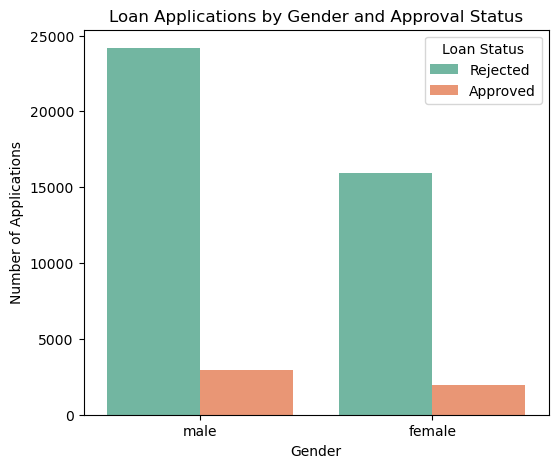

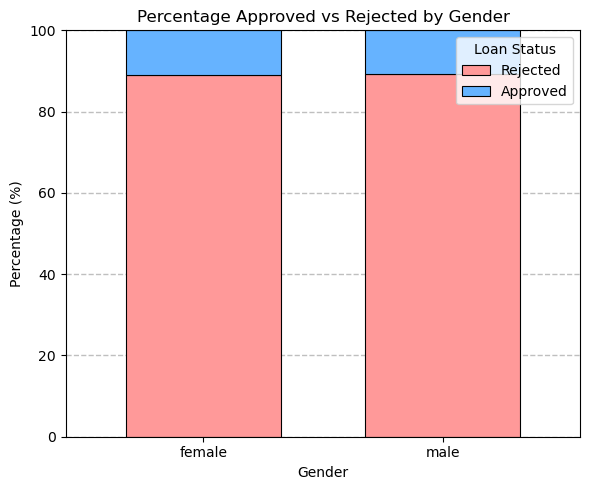

In [14]:
plt.figure(figsize=(6,5))
sns.countplot(
    data=loandf,
    x='person_gender',
    hue='loan_status',
    palette='Set2'
)
plt.xlabel('Gender')
plt.ylabel('Number of Applications')
plt.title('Loan Applications by Gender and Approval Status')
plt.legend(title='Loan Status', labels=['Rejected', 'Approved'])
plt.show()

# 100% stacked (shows approval rate per gender very clearly)

ct = pd.crosstab(loandf['person_gender'], loandf['loan_status'], normalize='index') * 100
# Create the plot and capture the Axes object
ax = ct.plot(
    kind='bar',
    stacked=True,
    color=['#ff9999', '#66b3ff'],        
    figsize=(6, 5),
    width=0.65,
    edgecolor='black',                   
    linewidth=0.8
)

# Add dashed horizontal lines every 20%
for y in range(0, 101, 20):
    ax.axhline(
        y=y,
        color='gray',
        linestyle='--',
        alpha=0.5,
        linewidth=1,
        zorder=0                    
    )
    handles, _ = ax.get_legend_handles_labels()           # get the real bar patches
ax.legend(
    handles=handles,
    labels=['Rejected', 'Approved'],                  # your nice labels
    title='Loan Status',
    loc='upper right'
)

# Final touches
ax.set_ylabel('Percentage (%)')
ax.set_title('Percentage Approved vs Rejected by Gender')
ax.set_xlabel('Gender')
#ax.legend(title='Loan Status', labels=['Rejected', 'Approved'], loc='upper right')
ax.set_ylim(0, 100)                    # makes scale clearer
plt.xticks(rotation=0)
plt.tight_layout()                     # prevents label cutoff
plt.show()

It is very close to being even as far as your chance of getting a loan and what gender you are.

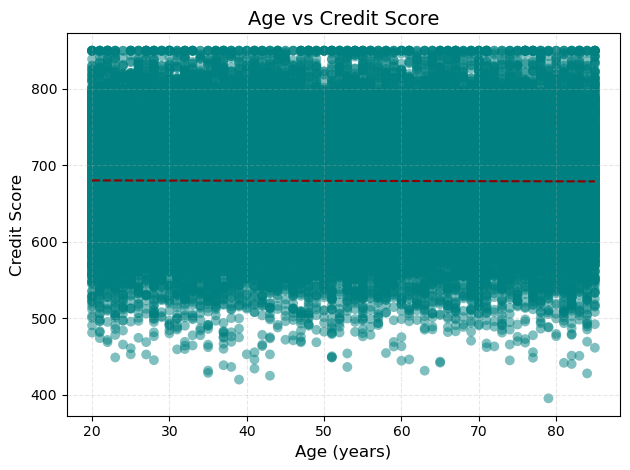

In [20]:

sns.scatterplot(
    data=loandf,
    x='person_age',
    y='credit_score',
    alpha=0.5,
    s=50,                     # point size – adjust if too crowded
    color='teal',
    edgecolor='none'
)

# Optional: add a simple trend line to see any overall pattern
sns.regplot(
    data=loandf,
    x='person_age',
    y='credit_score',
    scatter=False,
    color='darkred',
    line_kws={'linestyle': '--', 'linewidth': 1.5}
)

plt.title('Age vs Credit Score', fontsize=14)
plt.xlabel('Age (years)', fontsize=12)
plt.ylabel('Credit Score', fontsize=12)
plt.grid(True, alpha=0.3, linestyle='--')

# Optional: zoom in if there are extreme ages
# plt.xlim(18, 80)

plt.tight_layout()
plt.show()

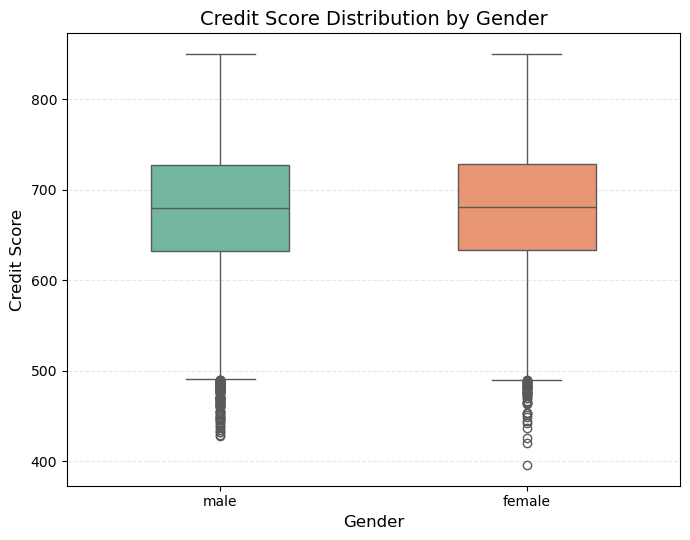

In [21]:
plt.figure(figsize=(7, 5.5))

sns.boxplot(
    data=loandf,
    x='person_gender',
    y='credit_score',
    hue='person_gender',
    palette='Set2',
    width=0.45,
    showfliers=True,          # shows outliers as points
    legend=False
)

plt.title('Credit Score Distribution by Gender', fontsize=14)
plt.xlabel('Gender', fontsize=12)
plt.ylabel('Credit Score', fontsize=12)
plt.grid(axis='y', alpha=0.3, linestyle='--')

plt.tight_layout()
plt.show()

Looking at the data for credit score compared to male and female as well as age. It is clear that there is no abnormal groups.

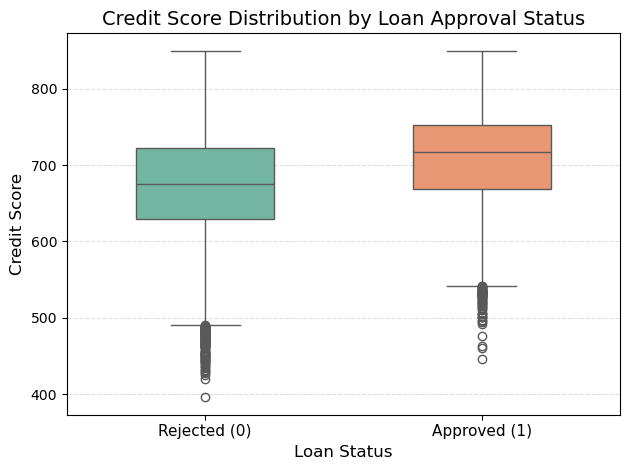

In [22]:
sns.boxplot(
    data=loandf,
    x='loan_status',
    y='credit_score',
    hue='loan_status',
    palette='Set2',
    width=0.5,
    showfliers=True,          # shows outliers as individual points
    legend=False
)

plt.xticks([0, 1], ['Rejected (0)', 'Approved (1)'], fontsize=11)
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Credit Score', fontsize=12)
plt.title('Credit Score Distribution by Loan Approval Status', fontsize=14)
plt.grid(axis='y', linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()

As expected the higher your score is the more likely you are of getting approved.

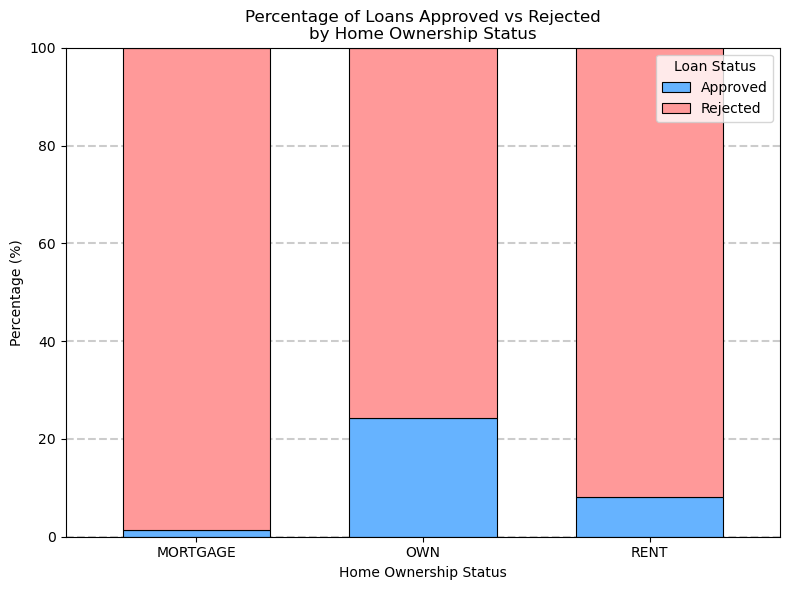

In [24]:
ct = pd.crosstab(
    loandf['person_home_ownership'],
    loandf['loan_status'],
    normalize='index'
) * 100

# Reorder columns: Approved (1) first, then Rejected (0)
ct = ct[[1, 0]]   # <--- key change

ax = ct.plot(
    kind='bar',
    stacked=True,
    color=['#66b3ff', '#ff9999'],          # blue first (approved), red on top (rejected)
    figsize=(8, 6),
    width=0.65,
    edgecolor='black',
    linewidth=0.8
)

for y in range(0, 101, 20):
    ax.axhline(y=y, color='gray', linestyle='--', alpha=0.4, zorder=0)

handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=['Approved', 'Rejected'],       # order matches stacking
    title='Loan Status',
    loc='upper right'
)

ax.set_xlabel('Home Ownership Status')
ax.set_ylabel('Percentage (%)')
ax.set_title('Percentage of Loans Approved vs Rejected\nby Home Ownership Status')
ax.set_ylim(0, 100)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

Owning a home seems to give you the greatest chance in being approved, and it makes sense that if you have a mortgage then taking on more debt would be difficult. 

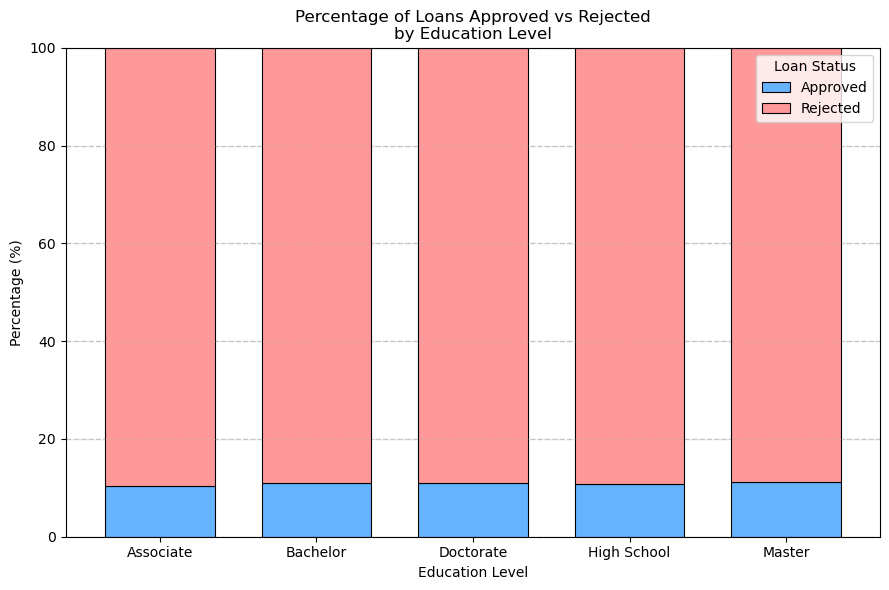

In [25]:
ct = pd.crosstab(
    loandf['person_education'],
    loandf['loan_status'],
    normalize='index'           # normalize within each education category
) * 100

# Reorder columns so Approved (1) is at the bottom
ct = ct[[1, 0]]

# Plot
ax = ct.plot(
    kind='bar',
    stacked=True,
    color=['#66b3ff', '#ff9999'],   # blue = Approved, red = Rejected
    figsize=(9, 6),
    width=0.7,
    edgecolor='black',
    linewidth=0.8
)

# Add reference lines for readability
for y in range(0, 101, 20):
    ax.axhline(y=y, color='gray', linestyle='--', alpha=0.4, linewidth=1, zorder=0)

# Fix legend (keeps solid colors)
handles, _ = ax.get_legend_handles_labels()
ax.legend(
    handles=handles,
    labels=['Approved', 'Rejected'],
    title='Loan Status',
    loc='upper right'
)

ax.set_xlabel('Education Level')
ax.set_ylabel('Percentage (%)')
ax.set_title('Percentage of Loans Approved vs Rejected\nby Education Level')
ax.set_ylim(0, 100)
plt.xticks(rotation=0)          # or 45 if labels are long
plt.grid(axis='y', alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

It looks like education has little to nothing to do with your approval status.

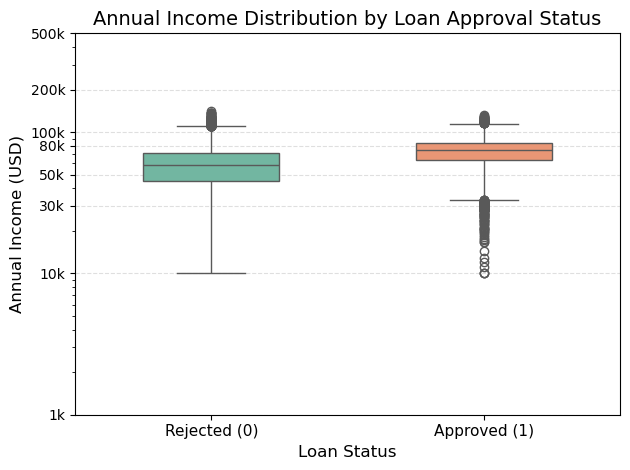

In [28]:
sns.boxplot(
    data=loandf,
    x='loan_status',
    y='person_income',
    hue='loan_status',
    palette='Set2',
    width=0.5,
    showfliers=True,           # shows outliers
    legend=False
)

plt.xticks([0, 1], ['Rejected (0)', 'Approved (1)'], fontsize=11)
plt.xlabel('Loan Status', fontsize=12)
plt.ylabel('Annual Income (USD)', fontsize=12)
plt.title('Annual Income Distribution by Loan Approval Status', fontsize=14)

# Use log scale because income is typically right-skewed with outliers
plt.yscale('log')

# Optional: nicer tick labels on log scale
plt.yticks([1000, 10000, 30000, 50000, 80000, 100000, 200000, 500000],
           ['1k', '10k', '30k', '50k', '80k', '100k', '200k', '500k'])

plt.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

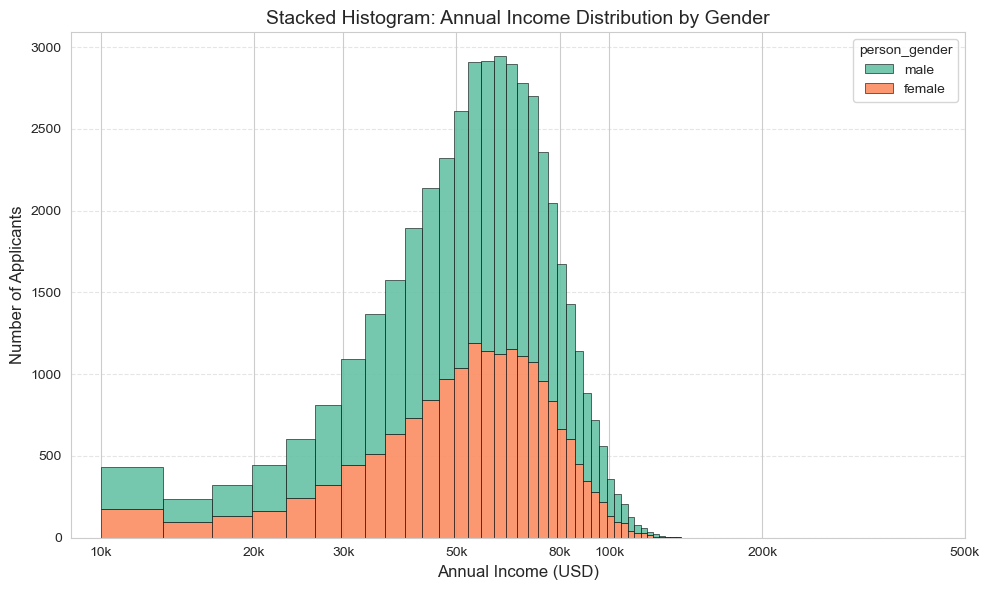

In [41]:
sns.set_style("whitegrid")

plt.figure(figsize=(10, 6))

sns.histplot(
    data=loandf,
    x='person_income',
    hue='person_gender',
    multiple='stack',          # this creates the stacked bars
    bins=40,                   # adjust: 30–60 depending on your data spread
    palette='Set2',            # or 'husl', 'Paired', etc.
    alpha=0.9,
    edgecolor='black',
    linewidth=0.4
)
handles, labels = plt.gca().get_legend_handles_labels()

plt.title('Stacked Histogram: Annual Income Distribution by Gender', fontsize=14)
plt.xlabel('Annual Income (USD)', fontsize=12)
plt.ylabel('Number of Applicants', fontsize=12)

# Because income is usually right-skewed, log scale helps visibility
plt.xscale('log')

# Nicer x-tick labels on log scale (adjust based on your data range)
plt.xticks(
    [ 10000, 20000, 30000, 50000, 80000, 100000, 200000, 500000],
    [ '10k', '20k', '30k', '50k', '80k', '100k', '200k', '500k']
)

#plt.legend( title = 'Gender' )    using plt.legend() keeps throwing error and not working correctly  
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.tight_layout()
plt.show()

Looking at all the data I do believe there is true discrimination between age, sex, and aproval rate. when looking at the stacked graph for gender vs approval, they seem to be even when it comes to the percentage approved. As for age, the aproval for elderly is very low, in fact if you are over 65 ther is a 0% chance of approval. everything else looks to be fair but age discrimination is the real problem.